In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv(r"C:\Users\Sanika\OneDrive\Desktop\ML_MINI\dataset\startup_dataset.csv")

In [4]:
df.head()

,Startup_Name,Funding_Amount,Break_Even_Point,TRL_Level,Number_of_Employees,Investors,Growth_Rate,Industry,Revenue,Marketing_Spend,...,Customer_Growth,Burn_Rate,Founder_Experience,Customer_Satisfaction,Company_Valuation,Employee_Retention_Rate,Monthly_Active_Users,Patent_Count,Global_Presence,Startup_Status
0,Mccarthy Inc,2.858102e+07,20,8,186,Google Ventures,89.274634,SaaS,3.024357e+07,6319742.61,...,75.326882,-2174.657706,10.559249,4.675177,5.388531e+08,84.872050,106862.890998,6.645147,1.410467,Successful
1,"Rivera, Martinez and Richardson",4.020761e+06,56,3,4,Google Ventures,51.073055,FinTech,8.017847e+05,163994.75,...,-15.589297,252952.125142,5.982155,3.212920,1.211364e+07,40.731306,65937.621932,0.117004,NaN,Failed
2,Gregory-Watkins,3.705180e+06,15,7,8,Accel,19.153730,Biotech,8.834071e+04,221834.86,...,35.247666,66547.352360,3.790470,3.918239,5.340925e+07,85.244404,84027.387352,0.996191,4.618046,Moderate
3,Hill Inc,9.312161e+06,17,8,34,Kalaari Capital,69.641404,HealthTech,1.934237e+07,1834445.55,...,38.679586,364452.513421,15.705194,4.261059,1.566384e+08,87.789782,384007.340614,7.646099,6.303783,Successful
4,Brock-Mcdonald,5.151838e+06,35,7,44,Kalaari Capital,4.758618,Biotech,9.205234e+05,452607.98,...,23.412914,329949.604457,8.785596,4.313637,6.972980e+07,66.489354,105567.355228,3.209853,32.711223,Moderate


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Startup_Name             700 non-null    object 
 1   Funding_Amount           700 non-null    float64
 2   Break_Even_Point         700 non-null    int64  
 3   TRL_Level                700 non-null    int64  
 4   Number_of_Employees      700 non-null    int64  
 5   Investors                700 non-null    object 
 6   Growth_Rate              700 non-null    float64
 7   Industry                 700 non-null    object 
 8   Revenue                  687 non-null    float64
 9   Marketing_Spend          679 non-null    float64
 10  Administration_Cost      700 non-null    float64
 11  Startup_Category         700 non-null    object 
 12  R&D_Spend                700 non-null    float64
 13  Innovation_Score         700 non-null    float64
 14  Market_Competition       7

In [6]:
df.describe()

,Funding_Amount,Break_Even_Point,TRL_Level,Number_of_Employees,Growth_Rate,Revenue,Marketing_Spend,Administration_Cost,R&D_Spend,Innovation_Score,Market_Competition,Customer_Growth,Burn_Rate,Founder_Experience,Customer_Satisfaction,Company_Valuation,Employee_Retention_Rate,Monthly_Active_Users,Patent_Count,Global_Presence
count,7.000000e+02,700.000000,700.000000,700.000000,700.000000,6.870000e+02,6.790000e+02,7.000000e+02,7.000000e+02,700.000000,700.000000,677.000000,7.000000e+02,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,684.000000,675.000000
mean,9.676508e+06,31.261429,5.158571,70.641429,35.681319,7.725974e+06,1.356876e+06,7.912148e+05,1.985782e+06,62.658895,5.474762,24.233792,5.704382e+05,6.285924,3.727302,8.987894e+07,71.658207,1.333840e+05,4.397135,12.870562
std,1.492959e+07,17.005308,2.102998,100.158722,37.590728,1.447092e+07,2.212749e+06,1.253186e+06,3.741814e+06,16.584338,2.122732,31.426015,8.018526e+05,4.389656,0.784702,1.846062e+08,14.585840,2.866903e+05,3.512405,13.110674
min,-3.933061e+06,3.000000,1.000000,1.000000,-58.654332,-5.318254e+06,1.181178e+04,4.217230e+03,-1.681440e+06,26.782203,0.567157,-59.105429,-4.223643e+04,-1.493280,1.640335,-8.654273e+07,35.122492,-1.242813e+05,-1.405349,-4.742514
25%,1.577162e+06,19.000000,4.000000,15.000000,8.478303,3.425923e+05,1.915819e+05,1.147215e+05,2.458426e+04,50.511641,3.867175,1.154657,2.230081e+05,2.955957,3.181265,-3.271680e+05,61.463886,2.754830e+03,1.398011,2.922451
50%,4.761432e+06,28.000000,5.000000,37.000000,34.235797,2.769042e+06,5.550776e+05,3.504702e+05,6.818714e+05,63.556442,5.468486,24.885911,3.841304e+05,5.989639,3.772860,3.419830e+07,73.282369,4.963977e+04,3.882694,8.424167
75%,1.178085e+07,40.000000,7.000000,87.000000,61.959519,9.017726e+06,1.535325e+06,9.556651e+05,2.218775e+06,75.149384,7.049482,49.179325,6.090077e+05,9.501301,4.340576,9.962382e+07,82.956624,1.450362e+05,6.733531,19.465892
max,1.282636e+08,93.000000,9.000000,873.000000,143.712178,1.157907e+08,1.826898e+07,1.570470e+07,4.399440e+07,101.867577,10.619999,101.407989,7.595381e+06,20.582345,5.272332,2.206599e+09,101.895096,3.182682e+06,19.519797,67.522419


In [7]:
df.isnull().sum()

Startup_Name                0
Funding_Amount              0
Break_Even_Point            0
TRL_Level                   0
Number_of_Employees         0
Investors                   0
Growth_Rate                 0
Industry                    0
Revenue                    13
Marketing_Spend            21
Administration_Cost         0
Startup_Category            0
R&D_Spend                   0
Innovation_Score            0
Market_Competition          0
Customer_Growth            23
Burn_Rate                   0
Founder_Experience          0
Customer_Satisfaction       0
Company_Valuation           0
Employee_Retention_Rate     0
Monthly_Active_Users        0
Patent_Count               16
Global_Presence            25
Startup_Status              0
dtype: int64

In [11]:
df.fillna(df.mean(), inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
print(df.shape)

(700, 25)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Startup_Name             700 non-null    int64  
 1   Funding_Amount           700 non-null    float64
 2   Break_Even_Point         700 non-null    int64  
 3   TRL_Level                700 non-null    int64  
 4   Number_of_Employees      700 non-null    int64  
 5   Investors                700 non-null    int64  
 6   Growth_Rate              700 non-null    float64
 7   Industry                 700 non-null    int64  
 8   Revenue                  700 non-null    float64
 9   Marketing_Spend          700 non-null    float64
 10  Administration_Cost      700 non-null    float64
 11  Startup_Category         700 non-null    int64  
 12  R&D_Spend                700 non-null    float64
 13  Innovation_Score         700 non-null    float64
 14  Market_Competition       7

In [15]:
print(df.columns)

Index(['Startup_Name', 'Funding_Amount', 'Break_Even_Point', 'TRL_Level',
       'Number_of_Employees', 'Investors', 'Growth_Rate', 'Industry',
       'Revenue', 'Marketing_Spend', 'Administration_Cost', 'Startup_Category',
       'R&D_Spend', 'Innovation_Score', 'Market_Competition',
       'Customer_Growth', 'Burn_Rate', 'Founder_Experience',
       'Customer_Satisfaction', 'Company_Valuation', 'Employee_Retention_Rate',
       'Monthly_Active_Users', 'Patent_Count', 'Global_Presence',
       'Startup_Status'],
      dtype='object')


Encode Categorical Columns

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

Correlation Heatmap

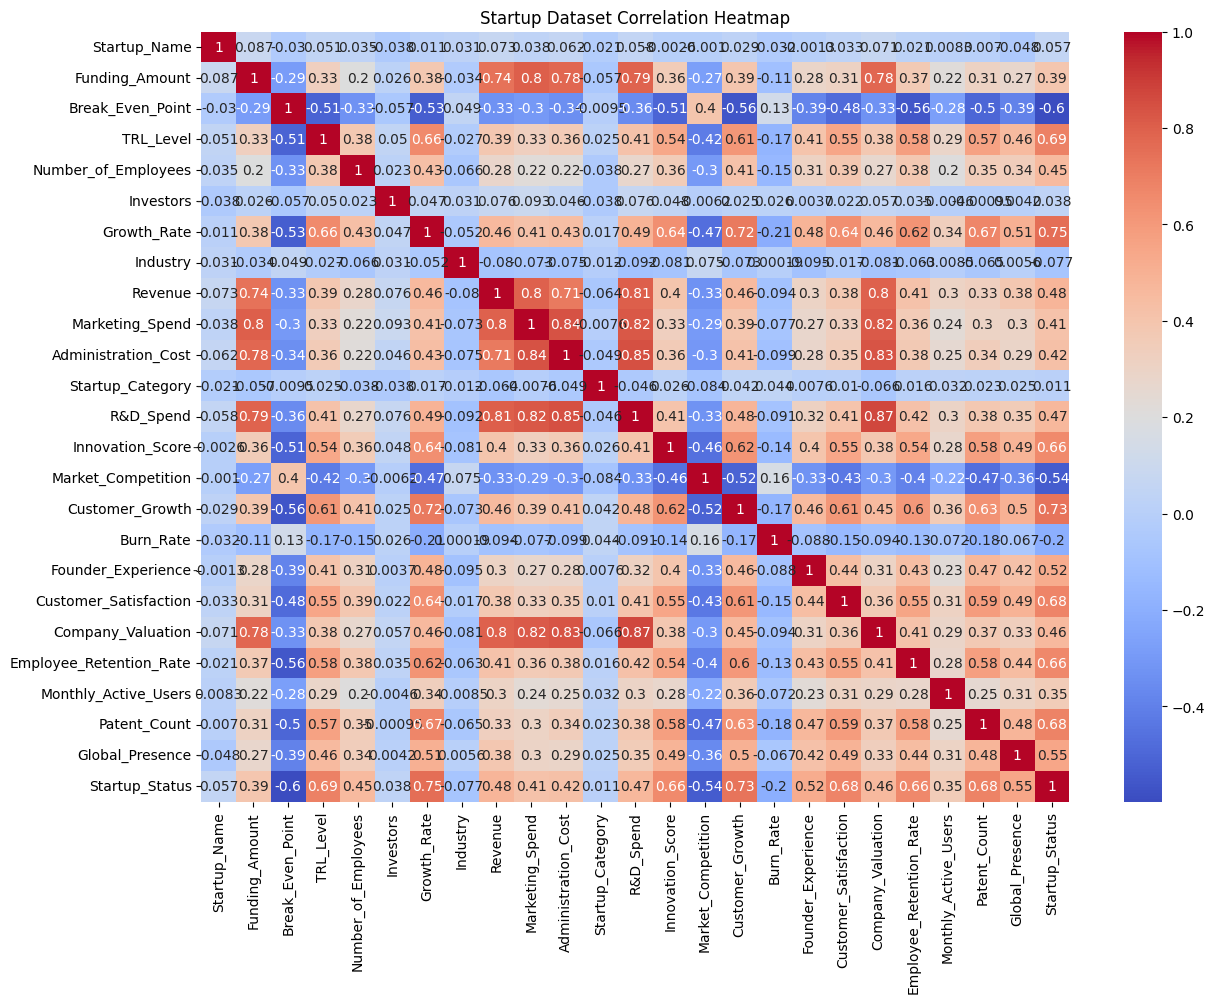

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Startup Dataset Correlation Heatmap")

plt.show()

Define Features and Target


In [18]:
X = df.drop("Startup_Status", axis=1)

y = df["Startup_Status"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

KNN

In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_knn))

Accuracy: 0.6357142857142857


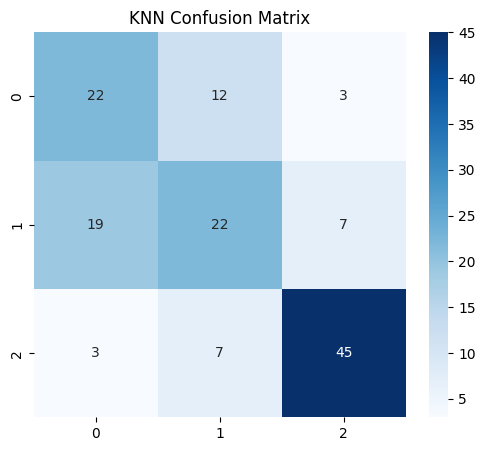

In [37]:
cm = confusion_matrix(y_test, pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("KNN Confusion Matrix")

plt.show()

SVM

In [38]:
from sklearn.svm import SVC
svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_svm))


Accuracy: 0.55


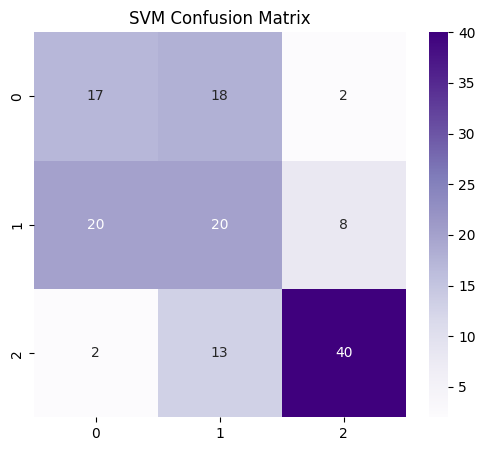

In [39]:
cm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("SVM Confusion Matrix")

plt.show()

Logistic Regression

In [20]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.7428571428571429


c:\Users\Sanika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


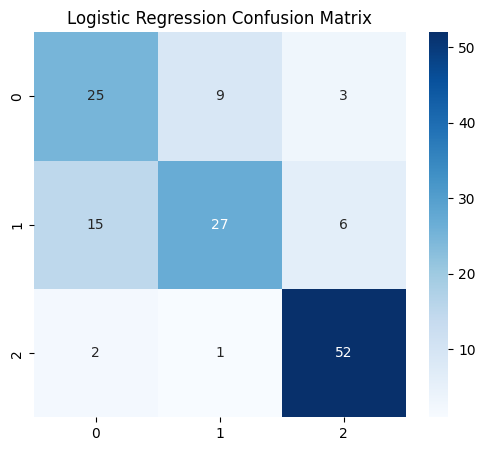

In [21]:
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Decision Tree

In [22]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))

Accuracy: 0.8071428571428572


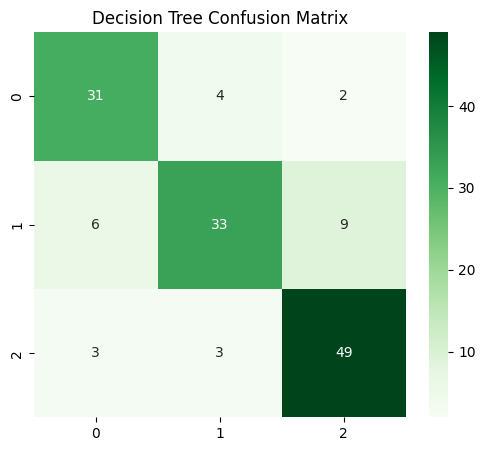

In [23]:
cm = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

Random Forest

In [24]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.9


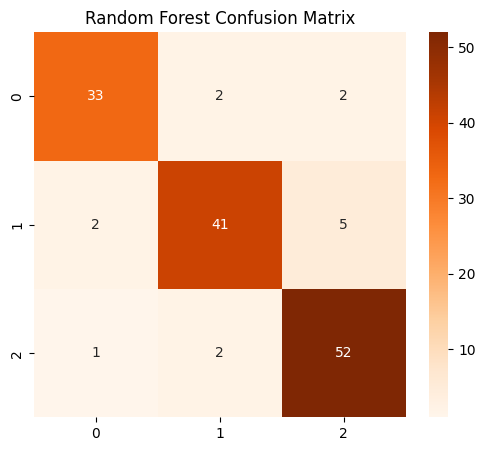

In [25]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

Gradient Boosting

In [26]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_gb))

Accuracy: 0.8857142857142857


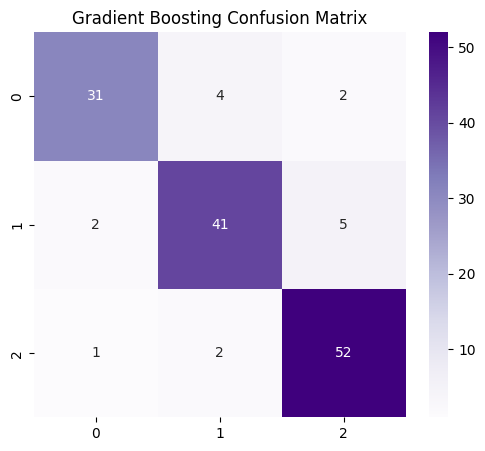

In [27]:
cm = confusion_matrix(y_test, pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Gradient Boosting Confusion Matrix")

plt.show()

XGBoost

In [28]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_xgb))

Accuracy: 0.8642857142857143


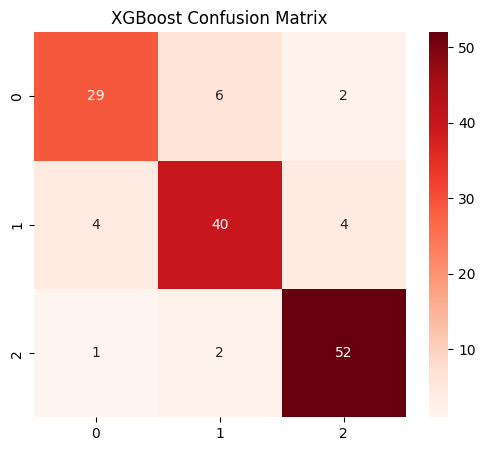

In [29]:
cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [30]:
print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.78      0.82        37
           1       0.83      0.83      0.83        48
           2       0.90      0.95      0.92        55

    accuracy                           0.86       140
   macro avg       0.86      0.85      0.86       140
weighted avg       0.86      0.86      0.86       140



Feature Importance

C:\Users\Sanika\AppData\Local\Temp\ipykernel_17392\192989672.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


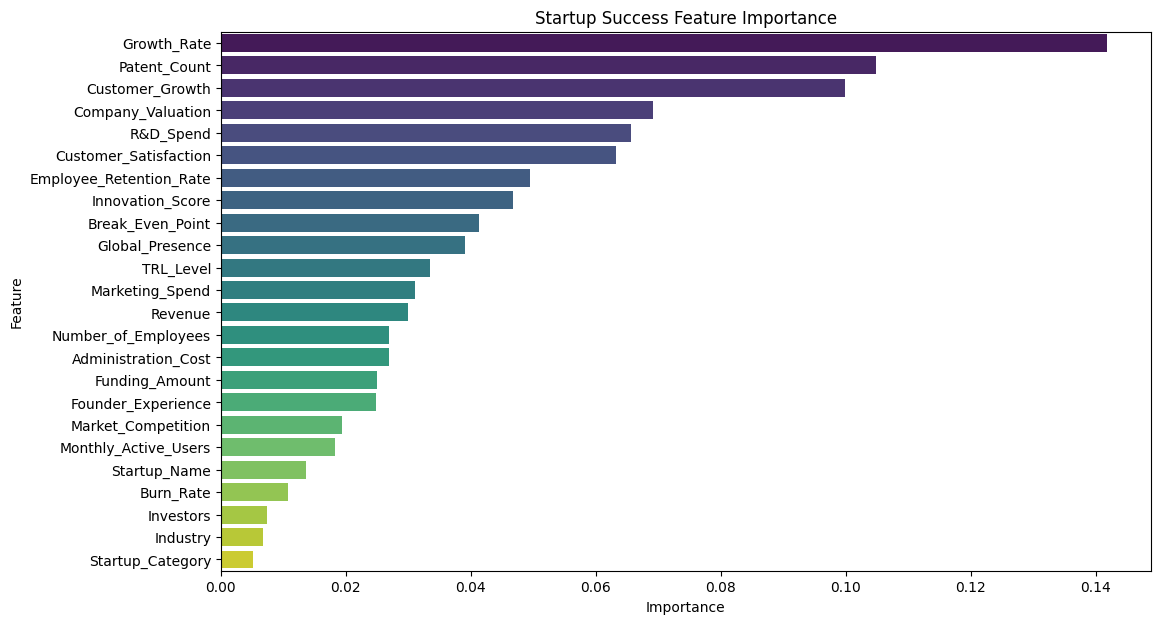

In [31]:
importance = rf.feature_importances_

feat = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat = feat.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat,
    palette='viridis'
)

plt.title("Startup Success Feature Importance")

plt.show()

In [40]:
results = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'KNN',

        'SVM',

        'Decision Tree',

        'Random Forest',

        'Gradient Boosting',

        'XGBoost'
    ],

    'Accuracy': [

        accuracy_score(y_test, pred_lr),

        accuracy_score(y_test, pred_knn),

        accuracy_score(y_test, pred_svm),

        accuracy_score(y_test, pred_dt),

        accuracy_score(y_test, pred_rf),

        accuracy_score(y_test, pred_gb),

        accuracy_score(y_test, pred_xgb)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.742857
1                  KNN  0.635714
2                  SVM  0.550000
3        Decision Tree  0.807143
4        Random Forest  0.900000
5    Gradient Boosting  0.885714
6              XGBoost  0.864286


C:\Users\Sanika\AppData\Local\Temp\ipykernel_17392\1645586141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


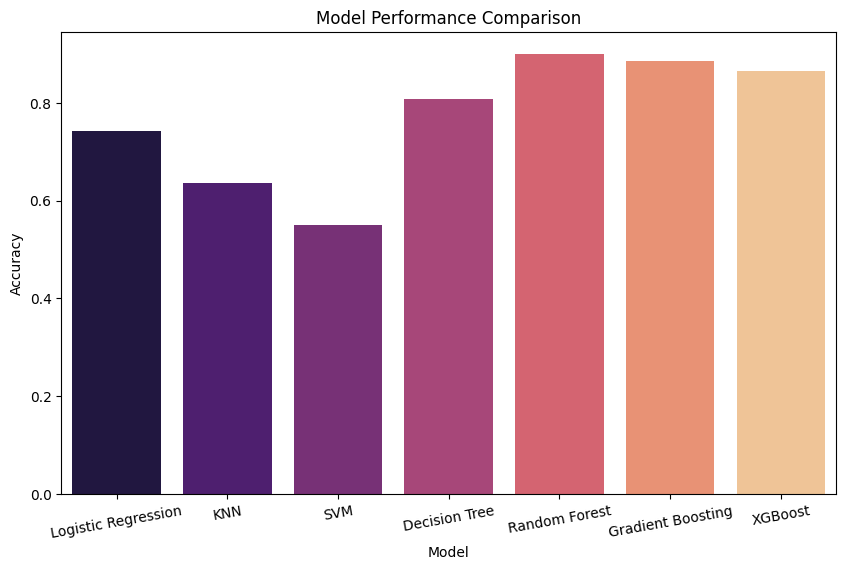

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette='magma'
)

plt.title("Model Performance Comparison")

plt.xticks(rotation=10)

plt.show()

In [44]:
RandomForestClassifier()

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
import joblib

joblib.dump(
    rf,
    "startup_success_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!
